In [1]:
!pip install -q ibm-watsonx-ai matplotlib networkx Pillow

In [10]:
import re, io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
from PIL import Image

def compile_and_show(tikz_code):
    nodes = {}

    # Strip LaTeX comments
    clean = re.sub(r'%[^\n]*', '', tikz_code)

    # Pattern 1: \node[opts] (id) {label}  ← state machine style
    for nid, label in re.findall(r'\\node\s*\[[^\]]*\]\s*\((\w+)\)\s*\{([^}]+)\}', clean):
        nodes[nid] = label.strip()
    # Pattern 2: \node (id) [opts] {label}
    for nid, label in re.findall(r'\\node\s*\((\w+)\)\s*\[[^\]]*\]\s*\{([^}]+)\}', clean):
        nodes[nid] = label.strip()
    # Pattern 3: \node (id) {label}  ← bare, no options at all
    for nid, label in re.findall(r'\\node\s*\((\w+)\)\s*\{([^}]+)\}', clean):
        nodes[nid] = label.strip()

    # ── Edge parsing (4 patterns) ──────────────────────────
    edges = []
    seen  = set()

    def add_edge(src, dst):
        if src in nodes and dst in nodes and (src, dst) not in seen:
            edges.append((src, dst))
            seen.add((src, dst))

    # 1) simple arrow:  (A) -> (B)  or  (A) -- (B)
    for src, dst in re.findall(r'\((\w+)\)\s*(?:--?>|--)\s*\((\w+)\)', clean):
        add_edge(src, dst)

    # 2) \draw ... (A) to (B)
    for src, dst in re.findall(r'\((\w+)\)\s+to\s+\((\w+)\)', clean):
        add_edge(src, dst)

    # 3) \path ... edge ... (A) ... (B)
    for src, dst in re.findall(r'\((\w+)\)\s+edge\s+(?:\[[^\]]*\]\s*)?\((\w+)\)', clean):
        add_edge(src, dst)

    # 4) \draw (A) -- node{..} (B)
    for src, dst in re.findall(r'\((\w+)\)\s*--\s*node\s*(?:\[[^\]]*\])?\s*\{[^}]*\}\s*\((\w+)\)', clean):
        add_edge(src, dst)

    if not nodes:
        print("⚠️ No nodes found. Raw TikZ:")
        print(tikz_code)
        return tikz_code

    print(f"   Nodes found : {list(nodes.keys())}")
    print(f"   Edges found : {edges}")

    # ── Color detection ────────────────────────────────────
    def get_color(nid):
        for seg in clean.split(";"):
            if f"({nid})" in seg:
                if "blue"   in seg: return "#AED6F1"
                if "red"    in seg: return "#F1948A"
                if "green"  in seg: return "#A9DFBF"
                if "orange" in seg: return "#FAD7A0"
                if "yellow" in seg: return "#F9E79F"
                if "violet" in seg: return "#D7BDE2"
                if "cyan"   in seg: return "#A2D9CE"
        return "#D5D8DC"

    node_list = list(nodes.keys())
    n = len(node_list)

    # ── Layout ─────────────────────────────────────────────
    # Try to detect circular/state-machine layout vs linear
    is_cyclic = any(src == node_list[-1] or dst == node_list[0]
                    for src, dst in edges)

    if is_cyclic and n >= 3:
        import math
        pos = {
            nid: (
                0.5 + 0.35 * math.cos(math.pi / 2 - 2 * math.pi * i / n),
                0.5 + 0.35 * math.sin(math.pi / 2 - 2 * math.pi * i / n)
            )
            for i, nid in enumerate(node_list)
        }
        fig_h = 5.5
        xlim, ylim = (0, 1), (0, 1)
    else:
        pos = {nid: (0.5, 1.0 - i / max(n - 1, 1) * 0.85 - 0.05)
               for i, nid in enumerate(node_list)}
        fig_h = max(4, n * 1.4)
        xlim, ylim = (0, 1), (-0.05, 1.05)

    # ── Draw ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5.5, fig_h))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis("off")

    BOX_W, BOX_H = 0.34, 0.09

    # Edges behind boxes
    for src, dst in edges:
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        ax.annotate("",
            xy=(x2, y2 + BOX_H / 2 if y2 < y1 else y2 - BOX_H / 2),
            xytext=(x1, y1 - BOX_H / 2 if y2 < y1 else y1 + BOX_H / 2),
            arrowprops=dict(
                arrowstyle="-|>",
                color="#2C3E50",
                lw=2,
                mutation_scale=20,
                connectionstyle="arc3,rad=0.0"
            )
        )

    # Boxes + labels
    for nid in node_list:
        x, y  = pos[nid]
        color = get_color(nid)
        rect  = mpatches.FancyBboxPatch(
            (x - BOX_W / 2, y - BOX_H / 2),
            BOX_W, BOX_H,
            boxstyle="round,pad=0.015",
            linewidth=1.8,
            edgecolor="#2C3E50",
            facecolor=color,
            zorder=3
        )
        ax.add_patch(rect)
        ax.text(x, y, nodes[nid],
                ha="center", va="center",
                fontsize=8.5, fontweight="bold",
                color="#1A1A2E", zorder=4,
                clip_on=False)

    plt.title("AI-Generated TikZ Diagram",
              fontsize=12, fontweight="bold",
              color="#2C3E50", pad=12)
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format="PNG", dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.close()
    buf.seek(0)
    img = Image.open(buf).copy()
    print("✅ Diagram rendered!")
    display(img)
    return tikz_code

print("✅ Renderer ready!")

✅ Renderer ready!


--- TikZ Code ---
\begin{tikzpicture}
\node (SourceCode) [startstop] {Source Code};
\node (Lexer) [process, below of=SourceCode] {Lexer};
\node (Parser) [process, below of=Lexer] {Parser};
\node (AST) [process, below of=Parser] {AST};
\node (CodeGenerator) [process, below of=AST] {Code Generator};
\node (MachineCode) [startstop, below of=CodeGenerator] {Machine Code};
\draw [arrow] (SourceCode) -- (Lexer);
\draw [arrow] (Lexer) -- (Parser);
\draw [arrow] (Parser) -- (AST);
\draw [arrow] (AST) -- (CodeGenerator);
\draw [arrow] (CodeGenerator) -- (MachineCode);
\end{tikzpicture}
-----------------
   Nodes found : ['SourceCode', 'Lexer', 'Parser', 'AST', 'CodeGenerator', 'MachineCode']
   Edges found : [('SourceCode', 'Lexer'), ('Lexer', 'Parser'), ('Parser', 'AST'), ('AST', 'CodeGenerator'), ('CodeGenerator', 'MachineCode')]
✅ Diagram rendered!


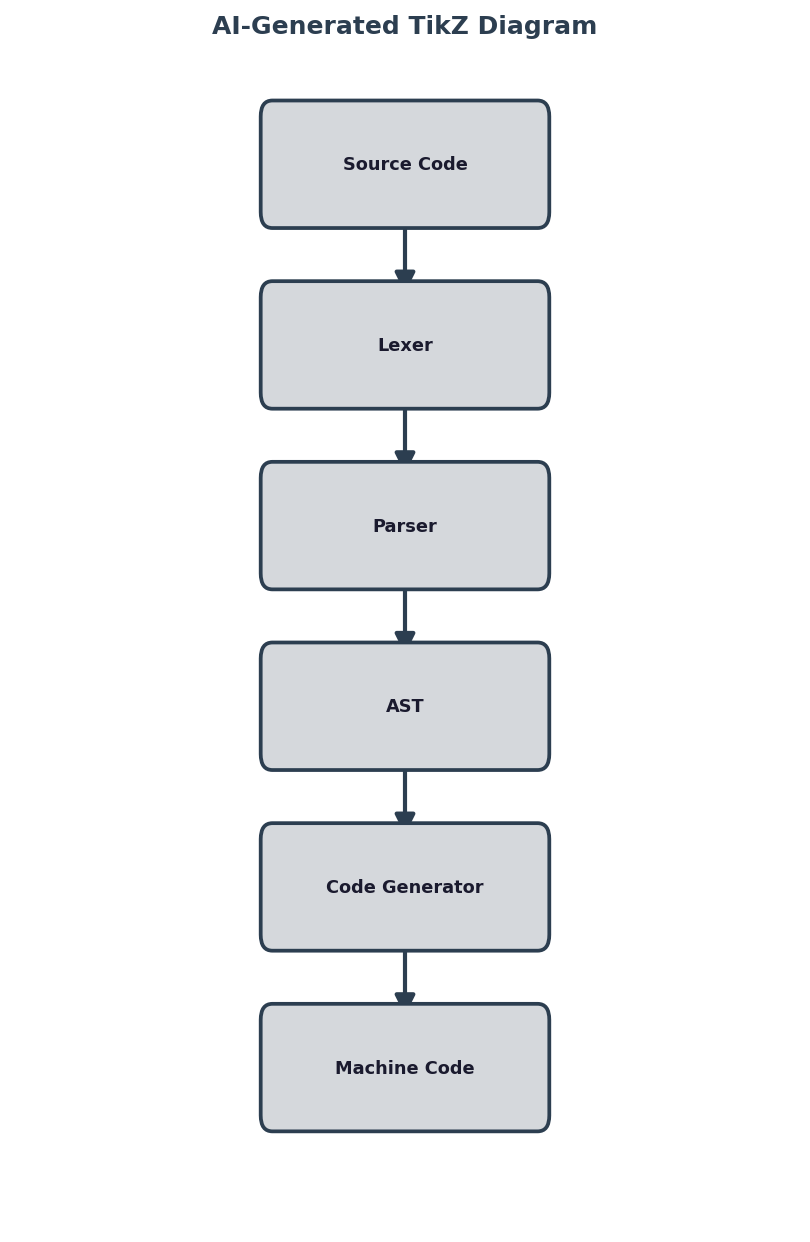

'\\begin{tikzpicture}\n\\node (SourceCode) [startstop] {Source Code};\n\\node (Lexer) [process, below of=SourceCode] {Lexer};\n\\node (Parser) [process, below of=Lexer] {Parser};\n\\node (AST) [process, below of=Parser] {AST};\n\\node (CodeGenerator) [process, below of=AST] {Code Generator};\n\\node (MachineCode) [startstop, below of=CodeGenerator] {Machine Code};\n\\draw [arrow] (SourceCode) -- (Lexer);\n\\draw [arrow] (Lexer) -- (Parser);\n\\draw [arrow] (Parser) -- (AST);\n\\draw [arrow] (AST) -- (CodeGenerator);\n\\draw [arrow] (CodeGenerator) -- (MachineCode);\n\\end{tikzpicture}'

In [11]:
current_code = generate_tikz(
    description  = "A flowchart: Source Code → Lexer → Parser → AST → Code Generator → Machine Code. Top-to-bottom layout.",
    diagram_type = "flowchart"
)
print("--- TikZ Code ---")
print(current_code)
print("-----------------")
compile_and_show(current_code)

--- Updated TikZ Code ---
\begin{tikzpicture}
\node (SourceCode) [startstop] {Source Code};
\node (Lexer) [process, below of=SourceCode, blue] {Lexer};
\node (Parser) [process, below of=Lexer, blue] {Parser};
\node (AST) [process, below of=Parser] {AST};
\node (CodeGenerator) [process, below of=AST] {Code Generator};
\node (MachineCode) [startstop, below of=CodeGenerator] {Machine Code};
\draw [arrow] (SourceCode) -- (Lexer);
\draw [arrow] (Lexer) -- (Parser);
\draw [arrow] (Parser) -- (AST);
\draw [arrow] (AST) -- (CodeGenerator);
\draw [arrow] (CodeGenerator) -- (MachineCode);
\end{tikzpicture}
-------------------------
   Nodes found : ['SourceCode', 'Lexer', 'Parser', 'AST', 'CodeGenerator', 'MachineCode']
   Edges found : [('SourceCode', 'Lexer'), ('Lexer', 'Parser'), ('Parser', 'AST'), ('AST', 'CodeGenerator'), ('CodeGenerator', 'MachineCode')]
✅ Diagram rendered!


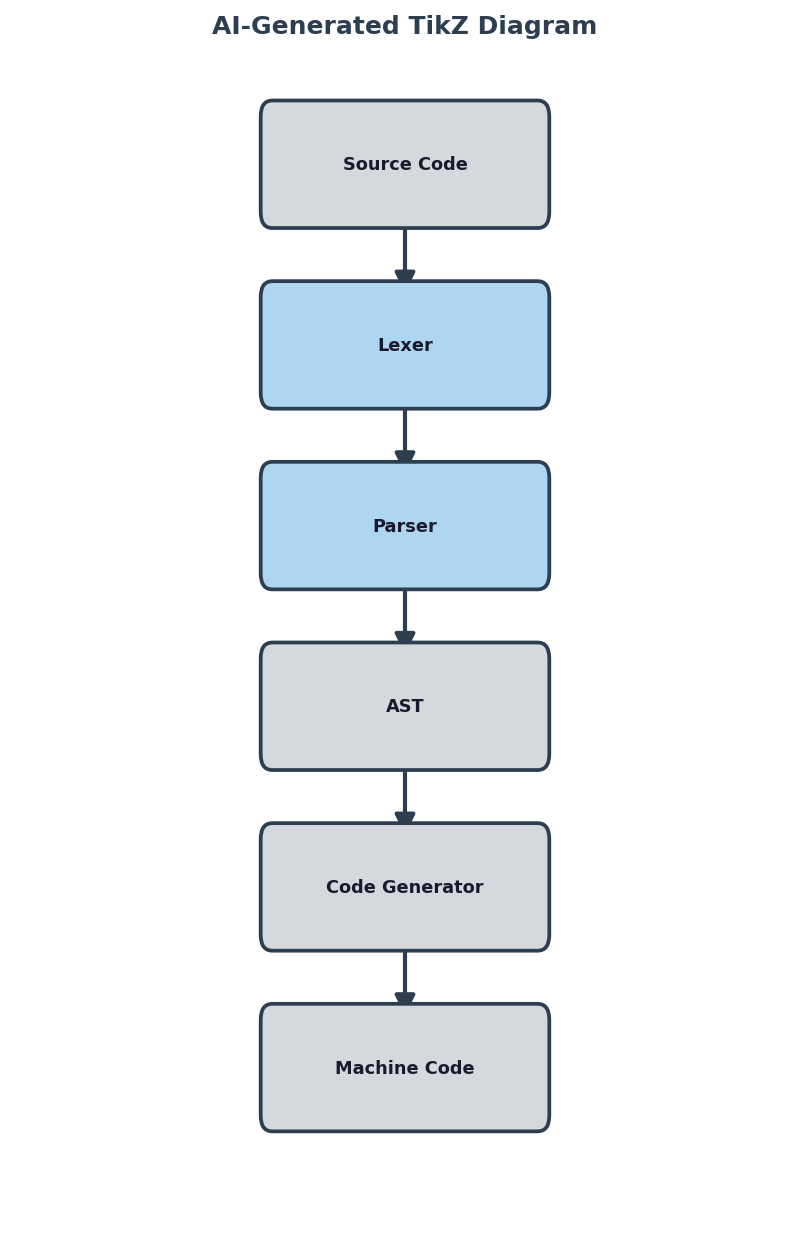

'\\begin{tikzpicture}\n\\node (SourceCode) [startstop] {Source Code};\n\\node (Lexer) [process, below of=SourceCode, blue] {Lexer};\n\\node (Parser) [process, below of=Lexer, blue] {Parser};\n\\node (AST) [process, below of=Parser] {AST};\n\\node (CodeGenerator) [process, below of=AST] {Code Generator};\n\\node (MachineCode) [startstop, below of=CodeGenerator] {Machine Code};\n\\draw [arrow] (SourceCode) -- (Lexer);\n\\draw [arrow] (Lexer) -- (Parser);\n\\draw [arrow] (Parser) -- (AST);\n\\draw [arrow] (AST) -- (CodeGenerator);\n\\draw [arrow] (CodeGenerator) -- (MachineCode);\n\\end{tikzpicture}'

In [12]:
current_code = refine_tikz(
    current_code = current_code,
    refinement   = "Add blue color to the Lexer and Parser nodes"
)
print("--- Updated TikZ Code ---")
print(current_code)
print("-------------------------")
compile_and_show(current_code)

   Nodes found : ['Idle']
   Edges found : []
✅ Diagram rendered!


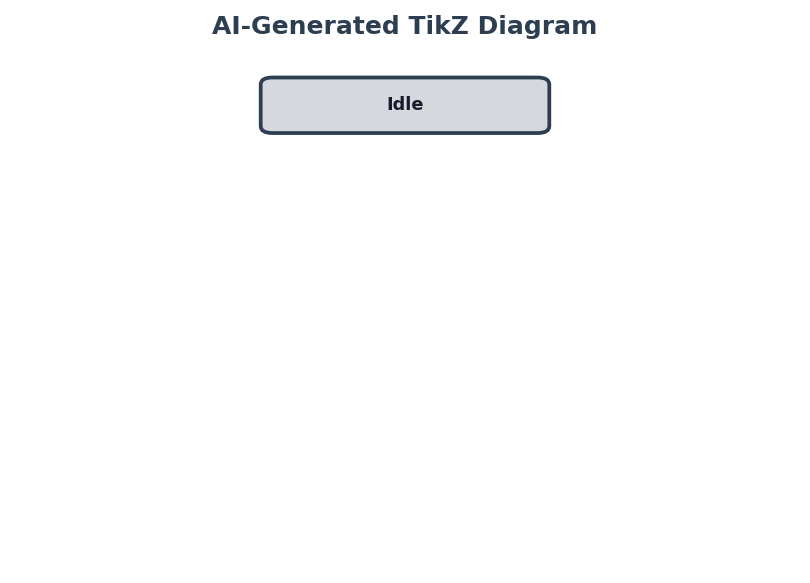

"\\begin{tikzpicture}\n[\n    ->,\n    >=stealth',\n    auto,\n    node distance=3cm,\n    thick,\n    main node/.style={\n        draw,\n        font=\\Large\\bfseries\n    }\n]\n\\node[main node] (Idle) {Idle};\n\\node[main node] (Processing) [below left of=Idle] {Processing};\n\\node[main node] (Success) [below right of=Idle] {Success};\n\\node[main node] (Error) [below right of=Processing] {Error};\n\\path[every node/.style={font=\\small}]\n(Idle) edge node {request} (Processing)\n(Processing) edge node {done} (Success)\n(Processing) edge node {fail} (Error)\n(Error) edge node {reset} (Idle);\n\\end{tikzpicture}"

In [13]:
current_code = generate_tikz(
    description  = "A state machine with states: Idle, Processing, Success, Error. Transitions: Idle→Processing on request, Processing→Success on done, Processing→Error on fail, Error→Idle on reset.",
    diagram_type = "state machine"
)
compile_and_show(current_code)